(08-38-wat-we-weten)=

# Wat we weten

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1863–2026, van Regnaults wortel-$t$-wet tot de terugblik van Santa-Clara.

**Wat we al weten.** Zevenendertig lectures lang volgde elk tijdvak hetzelfde patroon: een
theorie, een machine die haar liet toetsen, en een barst die het volgende tijdvak op gang
bracht. [De vorige lecture](#07-37-llms-en-efficientie) sloot de geschiedenis af met de
nieuwste machine, het taalmodel, en de vaststelling dat een model dat vertelt wat er in een
krantenkop staat, vertelt wat de prijs al weet.

**Welke vraag staat open.** Welke uitspraken over prijzen en rendementen staan na anderhalve
eeuw overeind, en hoe zeker zijn we van elk ervan?

Omdat dit een synthese is en geen lecture over één paper, is de vaste opbouw aangepast. Het
toy-voorbeeld en de simulatie gaan over de vier stellingen die een particuliere belegger
direct raken (diversificatie, kosten, de equity premium en handelsgedrag). De theorie is kort:
één propositie die zegt waarom sommige feiten zekerder zijn dan andere. De replicatie op echte
data bestaat uit elf korte demonstraties, één per stelling, telkens verwijzend naar de lecture
waar het mechanisme werd afgeleid. "Wat er brak" wordt de vraag welke van de elf het zwakst
staan.
```

## Overzicht

In de laatste sectie van zijn terugblik schrijft Pedro Santa-Clara op wat hij na een
loopbaan in het vak zeker meent te weten {cite}`SantaClara2026`. Het zijn elf stellingen, en
ze zijn opvallend bescheiden. Er staat geen model in, geen SDF en geen evenwicht; er staan
feiten in, van het soort dat een belegger kan gebruiken. Dat is zelf een uitkomst van de
geschiedenis die deze reeks heeft verteld (motief 3): het vak begon met één theorie die
getoetst werd, het CAPM, en eindigt met een lijst feiten waarvoor meerdere theorieën
concurreren. Wat overeind bleef, is wat meetbaar was.

Deze lecture loopt de elf stellingen langs. Per stelling geven we (a) de stelling in één zin,
in Santa-Clara's eigen openingszin; (b) waarom ze waar is, met een verwijzing naar de lecture
waar het mechanisme werd afgeleid; (c) één compacte demonstratie op de gecachte data van deze
reeks; (d) hoe zeker we zijn, met de standaardfout of de steekproefonzekerheid erbij; en (e)
de praktijkles. Die les is steeds een variant op de zin die door de hele reeks liep:
*"Everything I made that lasted came from bearing risk that was priced. Everything I lost came
from thinking I knew something the price did not."*

Hoe zeker een stelling is, volgt het 2%-motief uit [](#00-01-rendementen). Uitspraken over tweede
momenten en identiteiten zijn vrijwel zeker, uitspraken over eerste momenten kloppen in teken maar
niet in omvang, en uitspraken over zeldzame toestanden rusten op een handvol episodes. De
samenvattende tabel aan het eind maakt dat onderscheid per stelling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20260913)

## Intuïtie: waarom zou dit waar zijn?

Er is één gedachte die bijna alle elf stellingen draagt: *een prijs is een samenvatting van
wat veel mensen met geld op het spel denken, en wie die samenvatting wil verslaan, moet iets
weten of iets dragen wat die mensen niet willen dragen.* Iets weten is moeilijk en wordt met de
tijd moeilijker (stellingen 3 en 11). Iets dragen wordt beloond, maar alleen als het risico niet
gratis weg te geven is: risico dat weg te diversifiëren valt, levert niets op (stelling 1), en
risico dat in de slechtste toestanden toeslaat, levert juist veel op (stellingen 4, 6, 8 en 9).
Wat een belegger wel zeker weet, is wat hij betaalt (stelling 2).

De tweede gedachte is statistisch. Een gemiddeld rendement meten kost kalendertijd, een
variantie meten kost waarnemingen. Met dagdata heeft een eeuw 25 000 waarnemingen voor de
variantie maar nog steeds maar honderd jaar voor het gemiddelde. Daarom is volatiliteit
voorspelbaar en het rendement nauwelijks (stelling 5), en daarom is elke premie die we noemen
een getal met een standaardfout van één à twee procentpunt per jaar.

De derde gedachte gaat over crises. Arbitrage en hedging werken zolang de markt doorlopend handelt
en financiering beschikbaar is (stelling 7). In een crisis houdt beide op, en dan worden
hefboomposities gedwongen gesloten tegen de slechtste prijs (stellingen 9 en 10). Het bewijs
daarvoor is een mechanisme en een paar episodes, geen $t$-waarde.

## Toy-voorbeeld: dertig jaar sparen met de hand

Een belegger zet €100 000 opzij voor dertig jaar. Het verwachte (rekenkundige) rendement van
aandelen is 7% per jaar, voor elk aandeel en elke portefeuille gelijk, want idiosyncratisch
risico wordt niet beloond. De marktportefeuille heeft een volatiliteit van 20%. Een los aandeel
heeft een volatiliteit van 40% en een correlatie van 0,25 met elk ander aandeel, dus een
covariantie van $0{,}25 \times 0{,}40^2 = 0{,}04$, gelijk aan de marktvariantie.

Met [](#01-04-markowitz) is de variantie van een gelijkgewogen portefeuille van $N$ aandelen
$\bar v/N + (1-1/N)\bar c$. Voor drie aandelen: $0{,}16/3 + \tfrac23 \times 0{,}04 = 0{,}0533 +
0{,}0267 = 0{,}08$, een volatiliteit van 28,3%.

Bij lognormale rendementen groeit de *mediane* belegger met $g = \mu - c - \sigma^2/2$, met $c$
de jaarlijkse kosten. We vergelijken vier beleggers:

| Belegger | $\mu$ | $c$ | $\sigma^2$ | $g = \mu - c - \sigma^2/2$ | mediaan na 30 jaar |
|---|---|---|---|---|---|
| gespreid, goedkoop | 0,07 | 0,001 | 0,04 | 0,049 | $100\,000\,e^{1{,}47} = 434\,930$ |
| gespreid, duur | 0,07 | 0,020 | 0,04 | 0,030 | $100\,000\,e^{0{,}90} = 245\,960$ |
| drie aandelen, goedkoop | 0,07 | 0,001 | 0,08 | 0,029 | $100\,000\,e^{0{,}87} = 238\,690$ |
| drie aandelen, duur | 0,07 | 0,020 | 0,08 | 0,010 | $100\,000\,e^{0{,}30} = 134\,990$ |

(Met de hand: $e^{1{,}5} = 4{,}4817$ en $e^{-0{,}03} = 0{,}97045$, dus $e^{1{,}47} = 4{,}3493$;
$e^{0{,}9} = 2{,}4596$ en $e^{0{,}87} = 2{,}4596 \times 0{,}97045 = 2{,}3869$; $e^{0{,}3} = 1{,}3499$.)

Alle vier hebben hetzelfde *verwachte* eindvermogen voor kosten. De mediane belegger in de
laatste rij eindigt met minder dan een derde van de eerste. Van het verschil in groeivoet, 3,9
procentpunt, komt de helft uit kosten (1,9) en de helft uit het ongediversifieerde risico (2,0):
de variantie die niets oplevert, kost via $\sigma^2/2$ evenveel als een dure adviseur.

In [2]:
wealth0, years, mu = 100_000, 30, 0.07
sigma2_market = 0.20**2
v_bar, c_bar = 0.40**2, 0.25 * 0.40**2
sigma2_three = v_bar / 3 + (1 - 1 / 3) * c_bar

toy = pd.DataFrame(
    {"c": [0.001, 0.020, 0.001, 0.020],
     "sigma2": [sigma2_market, sigma2_market, sigma2_three, sigma2_three]},
    index=["gespreid, goedkoop", "gespreid, duur", "drie aandelen, goedkoop", "drie aandelen, duur"],
)
toy["g"] = mu - toy["c"] - toy["sigma2"] / 2
toy["mediaan na 30 jaar"] = wealth0 * np.exp(toy["g"] * years)
print(f"variantie drie aandelen = {sigma2_three:.4f} (hand: 0.0800)")
toy.round({"sigma2": 4, "g": 4, "mediaan na 30 jaar": 0})

variantie drie aandelen = 0.0800 (hand: 0.0800)


,c,sigma2,g,mediaan na 30 jaar
"gespreid, goedkoop",0.001,0.04,0.049,434924.0
"gespreid, duur",0.020,0.04,0.030,245960.0
"drie aandelen, goedkoop",0.001,0.08,0.029,238691.0
"drie aandelen, duur",0.020,0.08,0.010,134986.0


De code geeft dezelfde getallen als de tabel, op afronding van de laatste tientallen euro's na
(de tabel rondt $e^{1{,}47}$ af op vier decimalen).

## Theorie

### Waarom het ene feit zekerder is dan het andere

*Waarom zou dit waar zijn?* Een verschil in kosten of in ongediversifieerde variantie is een
verschil in de *drift* van het logvermogen dat elk jaar opnieuw wordt afgedragen, zeker en
lineair in de tijd. Het geluk dat dat verschil kan maskeren, groeit maar met de wortel van de
tijd. Na genoeg jaren wint de drift altijd; de vraag is alleen hoeveel jaren "genoeg" is.

:::{prf:proposition} Kosten, spreiding en de kans om te winnen
:label: thm-wat-we-weten-winkans

Laat belegger A de markt houden, met logrendement $r^A_{t+1} = \mu - c_A - \sigma_m^2/2 +
\sigma_m z_{t+1}$, en belegger B een portefeuille met bèta één op de markt, dezelfde verwachte
rendement $\mu$, extra idiosyncratische schokken $\sigma_\varepsilon \eta_{t+1}$ en kosten $c_B$,
met $z, \eta$ onafhankelijk standaardnormaal en i.i.d. Dan is

```{math}
:label: eq-wat-we-weten-winkans
\Pr\!\left(W^B_T > W^A_T\right) = \Phi\!\left(-\frac{\Delta\sqrt{T}}{\sigma_\varepsilon}\right),
\qquad
\Delta = (c_B - c_A) + \tfrac12 \sigma_\varepsilon^2 .
```

De kans daalt met $\sqrt{T}$, en ze hangt niet af van $\mu$: onzekerheid over de equity premium
treft beide beleggers gelijk.
:::

:::{prf:proof}
B heeft variantie $\sigma_m^2 + \sigma_\varepsilon^2$, dus $r^B_{t+1} = \mu - c_B - (\sigma_m^2 +
\sigma_\varepsilon^2)/2 + \sigma_m z_{t+1} + \sigma_\varepsilon \eta_{t+1}$. Het verschil is
$r^B_{t+1} - r^A_{t+1} = -\Delta + \sigma_\varepsilon \eta_{t+1}$; $\mu$ en $z$ vallen weg.
Gesommeerd over $T$ jaar is $\log(W^B_T/W^A_T) \sim N(-\Delta T, \sigma_\varepsilon^2 T)$, en
$\Pr(\log(W^B_T/W^A_T) > 0) = \Phi(-\Delta T/(\sigma_\varepsilon\sqrt T))$. $\square$
:::

Met de getallen van het toy-voorbeeld is $\Delta = 0{,}019 + \tfrac12 \times 0{,}04 = 0{,}039$ en
$\sigma_\varepsilon = 0{,}20$. Na dertig jaar is $\Delta\sqrt{T}/\sigma_\varepsilon = 0{,}039
\times 5{,}477/0{,}20 = 1{,}068$ en $\Phi(-1{,}068) = 0{,}143$. Eén op de zeven geconcentreerde,
dure beleggers verslaat de goedkope indexbelegger over een heel beleggersleven. Dat is geen
bewijs van vaardigheid; het is precies wat het model zonder vaardigheid voorspelt, en het is
genoeg om een industrie en een hoop anekdotes in stand te houden.

### Zekerheid als functie van wat er gemeten wordt

De propositie is een speciaal geval van de regel die [](#00-01-rendementen) opstelde. Een premie
$\mu$ met volatiliteit $\sigma$ is na $T$ jaar gemeten met $t = (\mu/\sigma)\sqrt{T}$, dus

```{math}
:label: eq-wat-we-weten-jaren
T_{\text{nodig}} = \left(\frac{t^\ast}{\mathrm{SR}}\right)^2,
```

met $\mathrm{SR} = \mu/\sigma$ de jaarlijkse Sharpe-ratio en $t^\ast$ de gewenste drempel. Voor
de markt ($\mathrm{SR} \approx 0{,}4$) en $t^\ast = 2$ is dat 25 jaar; voor de drempel 3 van
{cite:t}`HarveyLiuZhu2016` 56 jaar. Een factor met Sharpe-ratio 0,3 vraagt honderd jaar. Een
variantie is daarentegen na $T$ waarnemingen gemeten met een relatieve standaardfout
$\sqrt{2/T}$, onafhankelijk van de kalenderlengte zodra de frequentie hoog genoeg is
{cite}`Merton1980`. We gebruiken dat onderscheid in de samenvattende tabel:

- **hoog**: een identiteit, een tweede moment, of een eerste moment met $t > 3$ dat in
  onafhankelijke steekproeven (andere periodes, andere markten) terugkomt;
- **middel**: een eerste moment met het juiste teken maar een omvang die binnen twee
  standaardfouten sterk varieert, of een uitspraak die op een handvol episodes rust.

## Simulatie: dertig jaar, twee beleggers, onbekende premie

We simuleren de propositie met een onzekerheid erbij die in het toy-voorbeeld ontbrak: niemand
kent de equity premium. Per pad trekken we de ware premie uit $N(6\%, 2\%)$, de standaardfout
van een eeuw Amerikaanse data (stellingen 1, 2, 4 en 11 in één experiment). Belegger A houdt de
markt tegen 0,1% kosten per jaar. Belegger B houdt drie aandelen, handelt veel en betaalt 2% per
jaar aan kosten. Rente 2%, marktvolatiliteit 20%, idiosyncratische volatiliteit 20%, 30 jaar,
20 000 paden.

In [3]:
n_paths, T_sim, rf = 20_000, 30, 0.02
sigma_m, sigma_eps = 0.20, 0.20
cost_a, cost_b = 0.001, 0.020

premium = rng.normal(0.06, 0.02, size=n_paths)            # true equity premium differs per path
z = rng.standard_normal((T_sim, n_paths))                  # common market shocks
eta = rng.standard_normal((T_sim, n_paths))                # idiosyncratic shocks of B

mu_path = rf + premium
log_a = (mu_path - cost_a - sigma_m**2 / 2 + sigma_m * z).sum(axis=0)
log_b = (mu_path - cost_b - (sigma_m**2 + sigma_eps**2) / 2 + sigma_m * z + sigma_eps * eta).sum(axis=0)
wealth_a, wealth_b = wealth0 * np.exp(log_a), wealth0 * np.exp(log_b)

delta = (cost_b - cost_a) + sigma_eps**2 / 2
theory = stats.norm.cdf(-delta * np.sqrt(T_sim) / sigma_eps)
se_sim = np.sqrt(theory * (1 - theory) / n_paths)
bill = wealth0 * np.exp(rf * T_sim)

print(f"P(B > A): simulatie {np.mean(wealth_b > wealth_a):.3f}, "
      f"propositie {theory:.3f} (simulatie-SE {se_sim:.3f})")
pd.DataFrame(
    {"A: gespreid, goedkoop": [np.median(wealth_a), np.percentile(wealth_a, 5), np.percentile(wealth_a, 95),
                                np.mean(wealth_a < bill)],
     "B: geconcentreerd, duur": [np.median(wealth_b), np.percentile(wealth_b, 5), np.percentile(wealth_b, 95),
                                  np.mean(wealth_b < bill)]},
    index=["mediaan (€)", "5e percentiel (€)", "95e percentiel (€)", "kans achter bij de T-bill"],
).round(2)

P(B > A): simulatie 0.137, propositie 0.143 (simulatie-SE 0.002)


,"A: gespreid, goedkoop","B: geconcentreerd, duur"
mediaan (€),588195.02,179458.65
5e percentiel (€),72387.32,11473.69
95e percentiel (€),4515753.95,2692998.08
kans achter bij de T-bill,0.18,0.50


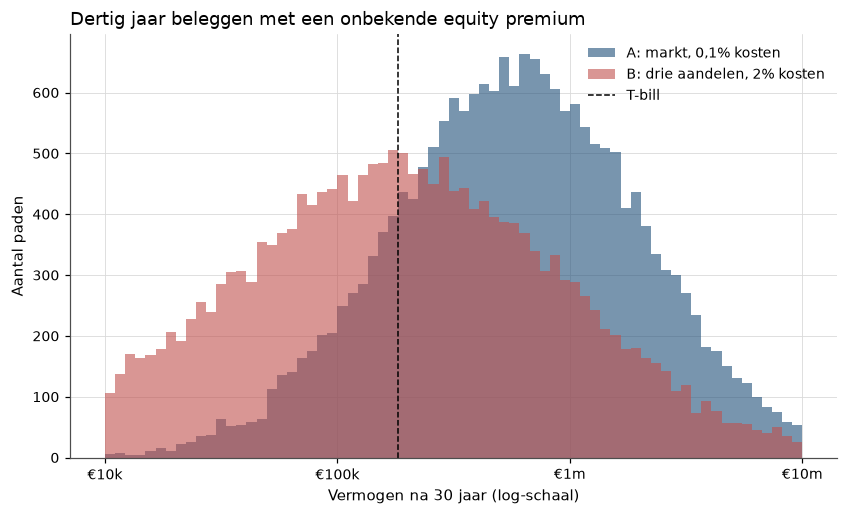

In [4]:
fig, ax = plt.subplots()
bins = np.linspace(4, 7, 70)
ax.hist(np.log10(wealth_a), bins=bins, alpha=0.6, label="A: markt, 0,1% kosten")
ax.hist(np.log10(wealth_b), bins=bins, alpha=0.6, label="B: drie aandelen, 2% kosten")
ax.axvline(np.log10(bill), color="black", lw=1, ls="--", label="T-bill")
ax.set_xticks([4, 5, 6, 7], ["€10k", "€100k", "€1m", "€10m"])
ax.set_xlabel("Vermogen na 30 jaar (log-schaal)")
ax.set_ylabel("Aantal paden")
ax.set_title("Dertig jaar beleggen met een onbekende equity premium")
ax.legend()
plt.show()

:::{figure} #cel-wat-we-weten-simulatie
:label: fig-wat-we-weten-simulatie
:width: 90%

De verdeling van B ligt naar links en is breder: kosten schuiven haar op, idiosyncratisch risico
maakt haar breder én schuift de mediaan verder op. De onzekerheid over de premie verbreedt beide
verdelingen, maar verandert de afstand ertussen niet.
:::

De simulatie bevestigt de propositie: in 13,7% van de paden eindigt B boven A, tegen 14,3% volgens
[](#eq-wat-we-weten-winkans). Het verschil is 2,4 simulatiestandaardfouten. Dat is aan de grote kant,
maar de propositie is onder de aannames van de simulatie exact, dus we schrijven het toe aan
steekproefruis en laten de seed staan. De mediane A eindigt met ongeveer €588 000, de mediane B met
€179 000. Die verhouding van 3,3 ligt dicht bij de $e^{0{,}039 \times 30} = 3{,}2$ van het
toy-voorbeeld: de onzekere premie verschuift beide beleggers evenveel.

Wat de simulatie toevoegt, is de spreiding. Het 5e percentiel van A ligt bij €72 000: ook de goedkope,
gespreide belegger heeft in één op de twintig paden na dertig jaar minder dan hij inlegde, deels door
pech in de markt en deels omdat de ware premie in dat pad laag was. De kans dat A achterblijft bij een
belegging in T-bills is 18%; voor B is die 50%. De geconcentreerde, dure belegger heeft na dertig jaar
dus een munt opgegooid tegen de spaarrekening, terwijl hij het volle risico van aandelen droeg. En één op
de zeven B's kan achteraf met recht zeggen dat hij de indexbelegger versloeg.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** De elf stellingen uit de sectie "What we know" van {cite:t}`SantaClara2026`, elk
gedemonstreerd met de aanpak van de lecture waar ze werd afgeleid; de gepubliceerde getallen staan
in die lectures.

**Wat.** Per stelling één tabel of figuur: het kernresultaat van de lecture die in de tabel aan het
eind bij die stelling staat.

**Data hier.** French (49 industrieën, FF3, momentum, bèta- en momentumportefeuilles, dagelijkse
markt), Goyal-Welch (jaarlijks en maandelijks), GSW, FRED (wisselkoersen en rentes) en Yahoo
(fondskoersen) via `hap.data`; de Pástor-Stambaugh-reeks uit de cache die [](#04-24-microstructuur)
aanmaakte.

**Verschil met het origineel.** Verkorte versies, zonder de controles en varianten van die
lectures. Voor (2) en (11) bestaan geen
gratis gegevens op het niveau van fondsen of rekeningen zonder survivorship bias; we gebruiken
overlevende fondsen en portefeuilles als benadering. Voor (7) hedgen we een optie op de index die
nooit verhandeld is, met de volatiliteit van de vorige maand als prijs.

**Verwachte afwijking.** (1) Volatiliteit dalend in $N$ naar een bodem boven nul; helling van het
gemiddelde rendement op idiosyncratische volatiliteit niet significant positief ($t < 2$). (2) Voor
elk fonds een standaardfout van het jaarlijkse verschil tussen 0,5 en 2 procentpunt; geen $t > 3$.
(3) Autocorrelatie positief met $t > 2$ in elk decennium vóór 1990; $|\rho_1| < 0{,}1$ in de jaren
2000 en 2010. (4) Rekenkundige premie tussen 6 en 9% met standaardfout rond 2; het laagste
20-jaarsgemiddelde minstens 4 procentpunt onder het hoogste; langste periode onder de vorige piek
minstens tien jaar. (5) $R^2$ van de logvariantie boven 0,3; $R^2$ van het rendement onder 0,02.
(6) Alle vier premies positief over de volledige steekproef met $t > 2$; voor HML een lagere
$t$-waarde in de tweede helft dan in de eerste. (7) Standaarddeviatie van het gehedgede resultaat
minder dan de helft van het ongehedgede; de slechtste gehedgede maand in 1929–1933, 1987, 2008 of
2020. (8) Alle hellingen positief en dichter bij één dan bij nul. (9) Positieve alpha over de
volledige steekproef, na 2003 niet significant; oktober 1987 of september 1998 of een maand in 2008
onder de vijf laagste liquiditeitsmaanden. (10) Aandeel vensters met margin call nul bij hefboom 1
en stijgend met de hefboom; gemiddeld eindvermogen met margin call lager dan zonder, voor elke
hefboom boven één. (11) Verliezers min winnaars negatief met $t < -3$; meer dan de helft van de
portefeuilles van drie industrieën een lagere Sharpe-ratio dan de markt. Wijkt een *teken* af, dan
zit de fout in de code.
```

In [5]:
ff3 = hap_data.french("F-F_Research_Data_Factors")
rf_m = ff3["RF"]
daily = hap_data.market_daily()

### 1. Diversificatie

**Stelling.** *"Diversification is the only free lunch, and it is a large one."*

**Waarom.** De variantie van een gelijkgewogen portefeuille is $\bar v/N + (1-1/N)\bar c$
([](#01-04-markowitz)): de eigen varianties verdwijnen, de covarianties niet. Wat verdwijnt kan
niemand beloond krijgen, want iedereen kan het gratis kwijt. Het CAPM ([](#02-08-capm)) en de APT
([](#03-11-apt-no-arbitrage)) maken daar een prijsvoorspelling van: alleen blootstelling aan
gemeenschappelijke factoren heeft een premie. {cite:t}`Markowitz1952` gaf de eerste helft,
{cite:t}`Sharpe1964` de tweede.

In [6]:
ind = hap_data.french("49_Industry_Portfolios").loc["1970":"2025"].dropna(axis=1)
ind_ex = ind.sub(rf_m, axis=0).dropna()
cov = ind_ex.cov().to_numpy()
n_ind = cov.shape[0]
v_ind = np.diag(cov).mean()
c_ind = (cov.sum() - np.trace(cov)) / (n_ind * (n_ind - 1))

curve = pd.DataFrame({"N": [1, 3, 10, 30, n_ind]})
curve["volatiliteit formule (%/jr)"] = 100 * np.sqrt(12 * (v_ind / curve["N"] + (1 - 1 / curve["N"]) * c_ind))


def mean_vol(n, draws):
    """Average annualised volatility of equal-weighted portfolios of n randomly drawn industries."""
    subsets = [rng.choice(n_ind, n, replace=False) for _ in range(draws)]
    return 100 * np.sqrt(12) * np.mean([np.sqrt(cov[np.ix_(s, s)].mean()) for s in subsets])


curve["volatiliteit 2000 trekkingen (%/jr)"] = [mean_vol(n, 2000 if n < n_ind else 1) for n in curve["N"]]

mkt = ind_ex.join(ff3["Mkt-RF"]).dropna()["Mkt-RF"]
X = sm.add_constant(mkt)
fits = {c: sm.OLS(ind_ex[c], X).fit() for c in ind_ex}
chars = {"bèta": pd.DataFrame({c: [f.params["Mkt-RF"]] for c, f in fits.items()}),
         "idio. vol": pd.DataFrame({c: [f.resid.std()] for c, f in fits.items()})}
fm = hap.stats.fama_macbeth(ind_ex, chars, lags=0)
print("Fama-MacBeth, 49 industrieën 1970-2025 (helling per maand):")
print(fm[["estimate", "se", "tstat"]].round(4).to_string())
curve.set_index("N").round(2)

Fama-MacBeth, 49 industrieën 1970-2025 (helling per maand):
           estimate      se   tstat
const        0.0057  0.0025  2.3158
bèta         0.0001  0.0028  0.0299
idio. vol    0.0149  0.0328  0.4533


,volatiliteit formule (%/jr),volatiliteit 2000 trekkingen (%/jr)
N,,
1,23.66,23.12
3,19.52,19.42
10,17.84,17.80
30,17.33,17.32
49,17.23,17.23


**Hoe zeker.** De bodem van de diversificatie ligt hier hoog, omdat een industrieportefeuille zelf al
honderden aandelen bevat. De gemiddelde industrie heeft 23,7% volatiliteit per jaar, de gelijkgewogen
portefeuille van alle 49 heeft 17,2%. Formule en trekkingen komen tot op een paar tienden overeen, en de
eerste drie industrieën halen al het grootste deel van de reductie. Voor losse aandelen, met een
volatiliteit van 40 à 50%, levert dezelfde bodem veel meer op ([](#01-04-markowitz)). Dit deel van de
stelling is een identiteit over tweede momenten, en daarmee zo zeker als iets in dit vak.

Het tweede deel, dat idiosyncratisch risico niet beloond wordt, is een uitspraak over een eerste moment en
dus zwakker. De Fama-MacBeth-helling op residuele volatiliteit is 0,015 per eenheid maandvolatiliteit, met
$t = 0{,}45$. We verwerpen dus niet dat de beloning nul is, maar een behoorlijke positieve beloning valt
ook binnen twee standaardfouten. De helling op bèta is evenmin significant ($t = 0{,}03$). Dat is de
vlakke security market line van [](#02-08-capm), geen weerlegging van diversificatie. Over het teken is de
literatuur het ook niet eens: {cite:t}`AngHodrickXingZhang2006` vonden dat aandelen met hoge
idiosyncratische volatiliteit juist *lage* gemiddelde rendementen hebben. De bèta's en residuele
volatiliteiten zijn over de hele steekproef geschat, dus met look-ahead; voor een uitspraak over het
*ontbreken* van een beloning is dat een milde vertekening. Zekerheid: hoog.

**Praktijkles.** Diversificatie is de enige plek waar een belegger iets krijgt zonder er iets voor
op te geven. Wie tien aandelen houdt omdat hij ze goed kent, betaalt daar elk jaar $\sigma^2/2$
voor (toy-voorbeeld), zonder dat iemand hem daarvoor een premie hoeft te betalen.

### 2. Kosten en belastingen

**Stelling.** *"Costs and taxes are the most reliable predictor of net returns."*

**Waarom.** De rekenkunde van {cite:t}`Sharpe1991` ([](#04-25-industrie)): vóór kosten is het
gemiddelde actieve rendement gelijk aan het passieve, dus na kosten ligt de gemiddelde actieve euro
achter met precies de kosten. {cite:t}`French2008` telde die kosten voor de Amerikaanse beurs op:
"Averaging over 1980–2006, I find investors spend 0.67% of the aggregate value of the market each
year searching for superior returns." Kosten zijn vooraf bekend; alpha is achteraf nauwelijks te
meten ([](#02-06-efficiente-markten), {prf:ref}`thm-wat-we-weten-winkans`). Belegging in een
indexfonds stelt bovendien de belasting op gerealiseerde winsten uit, een effect dat we met gratis
data niet kunnen meten.

In [7]:
funds = ["FMAGX", "AGTHX", "FCNTX", "PRGFX", "VWNDX", "DODGX", "TWCUX", "VFINX"]
fund_px = hap_data.yahoo(funds, "1980-01-01").resample("ME").last()
fund_ret = fund_px.pct_change().iloc[1:].loc[:"2026-07"]
diff = fund_ret.drop(columns="VFINX").sub(fund_ret["VFINX"], axis=0)

rows = {}
for name, d in diff.items():
    d = d.dropna()
    rows[name] = {"jaren": len(d) / 12, "gem. verschil (%/jr)": 1200 * d.mean(),
                  "SE (%/jr)": 1200 * d.std() / np.sqrt(len(d)), "t": d.mean() / (d.std() / np.sqrt(len(d))),
                  "tracking error (%/jr)": 100 * np.sqrt(12) * d.std()}
pd.DataFrame(rows).T.round(2)

,jaren,gem. verschil (%/jr),SE (%/jr),t,tracking error (%/jr)
AGTHX,46.50,0.35,1.08,0.32,7.36
DODGX,46.50,1.03,1.13,0.91,7.72
FCNTX,46.50,1.29,1.14,1.13,7.79
FMAGX,46.50,0.94,1.13,0.83,7.73
PRGFX,46.50,-1.55,0.99,-1.57,6.74
TWCUX,44.75,1.97,1.61,1.23,10.74
VWNDX,46.50,-0.74,1.27,-0.59,8.63


**Hoe zeker.** Geen van de zeven fondsen heeft een verschil met het indexfonds dat van nul te
onderscheiden is. De $t$-waarden liggen tussen $-1{,}57$ en $1{,}23$, de standaardfouten na 45 jaar
tussen 1,0 en 1,6 procentpunt per jaar. Met een tracking error van 7 à 11% per jaar is dat precies wat
[](#eq-wat-we-weten-jaren) voorspelt: om een voorsprong van één procentpunt met $t = 2$ te zien, heeft
een fonds met 7,5% tracking error $(2 \times 7{,}5/1)^2 = 225$ jaar nodig. Het gemiddelde van de zeven
verschillen is licht positief (0,47 procentpunt), maar dat is geen bewijs van vaardigheid. Dit zijn
fondsen die we kennen omdat ze na 45 jaar nog bestaan en groot zijn, en de survivorship bias uit
[](#02-05-crsp-tape) werkt in hun voordeel. Of een fonds zijn kosten terugverdient, is na een halve eeuw
nog niet te zeggen; de kosten zelf waren op de eerste dag bekend. Zekerheid: hoog.

**Praktijkles.** Van alles wat een belegger over de toekomst van zijn portefeuille kan zeggen, is
de kostenpost het enige getal met een standaardfout van nul. Wie een actief fonds kiest, ruilt een
zekere achterstand in tegen een onzekere voorsprong die hij, met de standaardfouten hierboven, pas
na tientallen jaren zou kunnen herkennen.

### 3. Snelheid van informatie

**Stelling.** *"Prices absorb public information fast."*

**Waarom.** Concurrentie om informatie ([](#02-06-efficiente-markten)): elke voorspelbare beweging
na publiek nieuws is een winstkans, en winstkansen worden weggehandeld tot de kosten van het
handelen ze niet meer waard maken {cite}`Fama1970`. De event study van
{cite:t}`FamaFisherJensenRoll1969` ([](#02-07-event-studies)) liet zien dat de koers vóór en op de
dag van een aankondiging beweegt en daarna niet meer. Met intradagdata, die we niet gratis hebben,
is die aanpassing voor aankondigingen van winsten en macrocijfers een kwestie van minuten tot uren;
met dagdata kunnen we alleen laten zien dat er na één dag weinig voorspelbaars overblijft.

In [8]:
r_daily = np.log1p(daily["Mkt"].dropna())
rows = {}
for start in range(1930, 2030, 10):
    x = r_daily.loc[f"{start}":f"{start + 9}"]
    rows[f"{start}s"] = {"dagen": len(x), "rho1": x.autocorr(1), "SE": 1 / np.sqrt(len(x)),
                         "t": x.autocorr(1) * np.sqrt(len(x))}
pd.DataFrame(rows).T.round(3)

,dagen,rho1,SE,t
1930s,2988.0,0.052,0.018,2.845
1940s,2918.0,0.157,0.019,8.502
1950s,2598.0,0.127,0.020,6.473
1960s,2489.0,0.202,0.020,10.069
1970s,2526.0,0.289,0.020,14.532
1980s,2528.0,0.131,0.020,6.572
1990s,2528.0,0.078,0.020,3.903
2000s,2515.0,-0.062,0.020,-3.109
2010s,2516.0,-0.038,0.020,-1.906
2020s,1653.0,-0.152,0.025,-6.176


**Hoe zeker.** In elk decennium vóór 1990 is de autocorrelatie positief en significant, met een piek
van 0,29 in de jaren zeventig ($t = 14{,}5$). In de jaren 2000 en 2010 is ze klein en negatief ($-0{,}06$
en $-0{,}04$). Bij een standaardfout van 0,02 zijn die verschillen scherp. Een deel van de vroege
autocorrelatie is geen trage informatieverwerking maar een meetartefact: kleine aandelen in de index
handelden niet elke dag, waardoor hun slotkoers achterliep ([](#02-06-efficiente-markten)). De jaren 2020
hebben een autocorrelatie van $-0{,}15$, maar [](#07-37-llms-en-efficientie) liet zien dat die vrijwel
geheel uit het coronajaar 2020 komt. Dat de *dag*-autocorrelatie verdween, is sterk bewijs dat er na één
dag weinig voorspelbaars overblijft. De claim van *uren* rust op intradag-event studies die we met gratis
data niet kunnen herhalen. Zekerheid: hoog voor de richting en de orde van grootte (een dag of minder),
middel voor de precieze snelheid.

**Praktijkles.** Een nieuwsbericht dat u leest, is geen informatie die de prijs niet heeft. Het is
de mildste vorm van *"thinking I knew something the price did not"*: niet een vergissing over de
waarde, maar over de volgorde waarin anderen het nieuws al hebben verwerkt.

### 4. De equity premium

**Stelling.** *"There is an equity premium, and it is large, and it is not constant."*

**Waarom.** Aandelen betalen slecht uit in toestanden waarin een euro veel waard is, en daarvoor
eisen beleggers een vergoeding. Dat de vergoeding groot is, is een feit dat geen standaardmodel
reproduceert ({cite:t}`MehraPrescott1985`, [](#03-13-equity-premium-puzzle)); dat ze varieert, volgt
uit de Campbell-Shiller-identiteit en de voorspelbaarheid op lange horizon
([](#04-20-voorspelbaarheid)); de drie grote verklaringen staan in [](#05-27-drie-antwoorden).
Mehra en Prescott rapporteerden voor 1889–1978 een premie van 6,18% (SE 1,76), in hun tabel 1.

In [9]:
gw = hap_data.goyal_welch("annual")
ep = (gw["CRSP_SPvw"] - gw["Rfree"]).dropna().rename("premie")
n_years = len(ep)
log_ep = np.log1p(gw["CRSP_SPvw"]) - np.log1p(gw["Rfree"])
rolling20 = np.expm1(log_ep.dropna().rolling(20).mean())
dd = hap.stats.drawdowns(ep)
underwater = (dd["drawdown"] < 0).astype(int)
spells = underwater.groupby((underwater == 0).cumsum()).sum()

print(f"{ep.index[0]:%Y}-{ep.index[-1]:%Y}: rekenkundige premie {100 * ep.mean():.2f}% "
      f"(SE {100 * ep.std() / np.sqrt(n_years):.2f}), meetkundig {100 * np.expm1(log_ep.dropna().mean()):.2f}%")
print(f"20-jaarsgemiddelde (meetkundig): laagste {100 * rolling20.min():.2f}% (tot {rolling20.idxmin():%Y}), "
      f"hoogste {100 * rolling20.max():.2f}% (tot {rolling20.idxmax():%Y})")
print(f"langste periode onder de vorige piek: {spells.max()} jaar; diepste drawdown {100 * dd.attrs['max_drawdown']:.1f}% "
      f"({dd.attrs['trough']:%Y})")

1926-2025: rekenkundige premie 8.82% (SE 1.99), meetkundig 6.76%
20-jaarsgemiddelde (meetkundig): laagste 0.51% (tot 1981), hoogste 15.15% (tot 1961)
langste periode onder de vorige piek: 15 jaar; diepste drawdown -70.4% (1932)


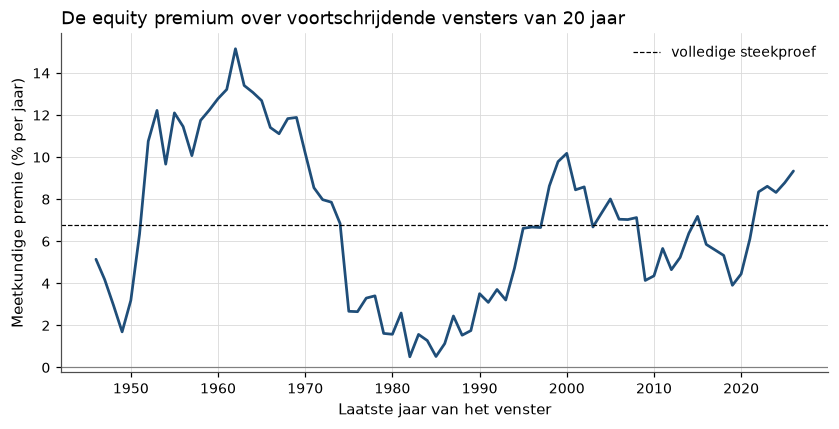

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rolling20.index, 100 * rolling20, lw=1.8)
ax.axhline(100 * np.expm1(log_ep.dropna().mean()), color="black", lw=0.8, ls="--", label="volledige steekproef")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Laatste jaar van het venster")
ax.set_ylabel("Meetkundige premie (% per jaar)")
ax.set_title("De equity premium over voortschrijdende vensters van 20 jaar")
ax.legend()
plt.show()

:::{figure} #cel-wat-we-weten-premie
:label: fig-wat-we-weten-premie
:width: 90%

Een premie die over de hele eeuw ruim zit, ligt over twintig jaar soms dicht bij nul en soms boven
de tien procent. Wie een beleggershorizon van twintig jaar heeft, leeft in één punt van deze lijn.
:::

**Hoe zeker.** De rekenkundige premie over 1926–2025 is 8,8% per jaar met een standaardfout van 2,0
procentpunt. De meetkundige premie, wat een belegger werkelijk samengesteld boven T-bills verdiende, is
6,8%. Een 95%-interval voor het rekenkundige gemiddelde loopt van ongeveer 4,9 tot 12,7%. Dat de premie
positief is, staat dus vast ($t = 4{,}4$); hoe groot ze is, weten we maar op een paar procentpunt
nauwkeurig. Santa-Clara's 5 à 7% ligt binnen dat interval. De tijdvariatie is groot: over de twintig jaar
tot 1981 was de meetkundige premie 0,5% per jaar, over de twintig jaar tot 1961 15,2%. De drawdowns zijn
lang: de langste periode waarin de cumulatieve voorsprong op T-bills onder haar vorige piek lag, duurde 15
jaar, en het diepste punt was $-70\%$ in 1932. Of die variatie een variërende discontovoet is of variërend
sentiment, is motief 2 ([](#05-33-fama-vs-shiller)); dát ze bestaat, staat vast. In [](#ex-wat-we-weten-2)
blijkt de premie over 1872–1926 een stuk kleiner. Zekerheid: hoog voor het bestaan en het teken, middel
voor de omvang.

**Praktijkles.** De premie is de beloning voor het dragen van risico dat beprijsd is, het
schoolvoorbeeld van *"risk that was priced"*. Maar het risico is echt: de beloning komt pas over
decennia, en wie tussentijds moet verkopen, krijgt haar niet.

### 5. Volatiliteit is voorspelbaar, rendementen nauwelijks

**Stelling.** *"Volatility is forecastable; returns barely are."*

**Waarom.** Volatiliteit is persistent (GARCH, [](#04-21-volatiliteit)) en met dagdata nauwkeurig te
meten {cite}`AndersenBollerslevDieboldLabys2003`; het gemiddelde rendement is slecht gemeten en de
voorspellers ervan werken buiten de steekproef nauwelijks {cite}`GoyalWelch2008`
([](#04-20-voorspelbaarheid)). Het is het 2%-motief in één zin: een tweede moment wordt met meer
waarnemingen beter, een eerste moment alleen met meer jaren.

In [11]:
d_ex = daily["Mkt-RF"].dropna()
rv = (d_ex**2).groupby(d_ex.index.to_period("M")).sum()
rv.index = rv.index.to_timestamp(how="end").normalize()
gw_m = hap_data.goyal_welch("monthly")

frame = pd.DataFrame({"log_rv": np.log(rv), "rx": ff3["Mkt-RF"], "dp": gw_m["dp"]}).loc["1927":"2025"]
tests = {
    "log RV(t+1) op log RV(t)": (frame["log_rv"].shift(-1), frame[["log_rv"]]),
    "rendement(t+1) op log D/P(t)": (frame["rx"].shift(-1), frame[["dp"]]),
    "rendement(t+1) op rendement(t)": (frame["rx"].shift(-1), frame[["rx"]]),
}
rows = {}
for name, (y, x) in tests.items():
    fit = hap.stats.newey_west(y, x, lags=6)
    rows[name] = {"helling": fit.params.iloc[1], "t (NW)": fit.tvalues.iloc[1], "R2": fit.rsquared,
                  "maanden": int(fit.nobs)}
pd.DataFrame(rows).T.round(3)

,helling,t (NW),R2,maanden
log RV(t+1) op log RV(t),0.726,26.550,0.527,1187.0
rendement(t+1) op log D/P(t),0.005,1.212,0.002,1187.0
rendement(t+1) op rendement(t),0.093,1.721,0.009,1187.0


**Hoe zeker.** De log gerealiseerde variantie van de volgende maand heeft een $R^2$ van 0,53 op die
van deze maand, met een helling van 0,73 en een standaardfout van 0,03. Het rendement van de volgende
maand heeft een $R^2$ van 0,002 op de dividend-prijsratio en 0,009 op het eigen rendement van deze maand,
beide met $t < 2$. Het verschil is twee ordes van grootte, en een betere methode verandert dat niet.
[](#04-21-volatiliteit) liet zien dat GARCH-voorspellingen met parameters uit 1969 buiten de steekproef
41 tot 48% van de logvariantie verklaren. [](#04-20-voorspelbaarheid) liet zien dat de
dividend-prijsratio buiten de steekproef een $R^2$ van ongeveer $-4\%$ heeft. Een kleine voorspelbaarheid
van rendementen op lange horizon is daarmee niet uitgesloten; ze is alleen niet bruikbaar. Zekerheid:
hoog.

**Praktijkles.** Wie risico wil sturen, heeft een betrouwbaar instrument: schaal de positie terug
als de volatiliteit hoog is, zoals Barroso en Santa-Clara met momentum deden ([](#04-19-momentum)).
Wie uit dezelfde data de *richting* van de markt denkt te halen, meent iets te weten wat de prijs
niet weet.

### 6. Robuuste premies: value, momentum, carry en low-volatility

**Stelling.** *"A few risk premia are robust across markets, time and asset classes."*

**Waarom.** Value en size als factoren {cite}`FamaFrench1993` ([](#04-18-fama-french)), momentum
{cite}`JegadeeshTitman1993` ([](#04-19-momentum)), valuta-carry {cite}`LustigRoussanovVerdelhan2011`
([](#05-30-wisselkoersen)) en de te vlakke security market line ({cite:t}`FrazziniPedersen2014`,
[](#02-08-capm)). {cite:t}`AsnessMoskowitzPedersen2013` vonden value en momentum in acht markten
tegelijk. Of het risico of vergissing is, laat de reeks open; dat de premies in de data staan, niet.

In [12]:
beta_p = hap_data.french("Portfolios_Formed_on_BETA").sub(rf_m, axis=0).dropna()
low_beta = (beta_p["Lo 20"] - beta_p["Hi 20"]).rename("low-beta")
mom = hap_data.french("F-F_Momentum_Factor")["Mom"]

# FX carry as in lecture 30: sort G10 currencies on the interest-rate differential with the dollar.
fx_codes = {"GBP": ("DEXUSUK", True), "JPY": ("DEXJPUS", False), "CHF": ("DEXSZUS", False),
            "CAD": ("DEXCAUS", False), "AUD": ("DEXUSAL", True), "NZD": ("DEXUSNZ", True),
            "NOK": ("DEXNOUS", False), "SEK": ("DEXSDUS", False), "EUR": ("DEXUSEU", True)}
months = pd.date_range("1976-01-31", "2025-12-31", freq="ME")
month_end = lambda code: hap_data.fred(code)[code].dropna().resample("ME").last()
rate = lambda code: hap_data.fred(code)[code].dropna().resample("ME").mean() / 100
log_spot = pd.DataFrame({c: (1 if usd else -1) * np.log(month_end(code))
                         for c, (code, usd) in fx_codes.items()}).reindex(months)
rates = pd.DataFrame({
    "USD": rate("IR3TIB01USM156N"), "GBP": rate("IR3TIB01GBM156N"),
    "JPY": rate("IR3TCD01JPM156N").loc[:"2002-03"].combine_first(rate("IR3TIB01JPM156N")),
    "CHF": rate("IRSTCI01CHM156N").loc[:"1999-06"].combine_first(rate("IR3TIB01CHM156N")),
    "CAD": rate("IR3TIB01CAM156N"), "AUD": rate("IR3TIB01AUM156N"), "NZD": rate("IR3TIB01NZM156N"),
    "NOK": rate("IR3TIB01NOM156N"), "SEK": rate("IR3TIB01SEM156N"), "EUR": rate("IR3TIB01DEM156N").loc["1999":],
}).reindex(months)
rate_diff = rates[list(fx_codes)].sub(rates["USD"], axis=0) / 12
rx_next = rate_diff + log_spot.diff().shift(-1)
ranks = rate_diff.where(rx_next.notna()).rank(axis=1, method="first")
count = ranks.notna().sum(axis=1)
group = np.ceil(3 * ranks.div(count, axis=0))
carry = (rx_next.where(group == 3).mean(axis=1) - rx_next.where(group == 1).mean(axis=1))[count >= 6]
carry.index = carry.index + pd.offsets.MonthEnd(1)

premia = {"HML (value)": ff3["HML"], "Mom (momentum)": mom, "carry (valuta)": carry.rename("carry"),
          "low-beta, CAPM-alpha": low_beta}
rows = {}
for name, series in premia.items():
    s = series.dropna()
    halves = (s.iloc[: len(s) // 2], s.iloc[len(s) // 2 :])
    if name.startswith("low-beta"):
        t_of = lambda x: hap.stats.newey_west(x, ff3["Mkt-RF"].reindex(x.index), lags=6).tvalues.iloc[0]
        mean = 1200 * hap.stats.newey_west(s, ff3["Mkt-RF"].reindex(s.index), lags=6).params.iloc[0]
    else:
        t_of = lambda x: x.mean() / (x.std() / np.sqrt(len(x)))
        mean = 1200 * s.mean()
    rows[name] = {"periode": f"{s.index[0]:%Y}-{s.index[-1]:%Y}", "gem. of alpha (%/jr)": round(mean, 2),
                  "t volledig": round(t_of(s), 2), "t eerste helft": round(t_of(halves[0]), 2),
                  "t tweede helft": round(t_of(halves[1]), 2), "Sharpe (jr)": round(np.sqrt(12) * s.mean() / s.std(), 2)}
pd.DataFrame(rows).T

,periode,gem. of alpha (%/jr),t volledig,t eerste helft,t tweede helft,Sharpe (jr)
HML (value),1926-2026,4.26,3.46,2.89,1.92,0.35
Mom (momentum),1927-2026,7.41,4.55,3.22,3.23,0.46
carry (valuta),1979-2025,3.67,3.01,2.58,1.58,0.44
"low-beta, CAPM-alpha",1963-2026,2.8,1.35,0.83,1.27,-0.16


**Hoe zeker.** Drie van de vier premies staan zoals verwacht: HML 4,3% per jaar sinds 1926
($t = 3{,}5$), momentum 7,4% sinds 1927 ($t = 4{,}6$) en valuta-carry 3,7% sinds 1979 ($t = 3{,}0$). De
vierde niet. Het verschil tussen het laagste en het hoogste bèta-quintiel heeft een CAPM-alpha van 2,8%
per jaar met $t = 1{,}35$, onder de verwachte drempel van 2. Dat is een echte afwijking, geen fout in het
teken: de alpha is positief en de ruwe Sharpe-ratio negatief ($-0{,}16$), zoals het hoort voor een
portefeuille die short gaat in de aandelen met de hoogste bèta. Een deel van het verschil met
{cite:t}`FrazziniPedersen2014` zit in de constructie. Zij brengen beide benen met hefboom naar een bèta
van één, zodat de portefeuille marktneutraal is, en gebruiken naast Amerikaanse aandelen ook
internationale markten en andere activaklassen. Wij vergelijken twee value-weighted quintielen zonder
hefboom over 63 jaar. [](#02-08-capm) vond voor alleen het laagste bèta-deciel een alpha van 0,21% per
maand met $t = 2{,}53$. Low-beta is in onze data dus de zwakste van de vier.

De verwachte verzwakking van HML is er ook: $t = 2{,}89$ in de eerste helft en $1{,}92$ in de tweede. Voor
carry daalt de $t$-waarde van $2{,}58$ naar $1{,}58$; alleen momentum is in beide helften even sterk. Bij
Sharpe-ratio's van 0,35 à 0,46 vraagt $t = 3$ volgens [](#eq-wat-we-weten-jaren) 40 à 75 jaar data, meer
dan een halve steekproef biedt. Zekerheid: hoog voor value en momentum over
lange steekproeven en meerdere markten; middel voor carry, voor low-beta en voor de omvang van elke premie
na publicatie.

**Praktijkles.** Dit zijn de premies waarmee DFA en AQR hun bedrijven bouwden ([](#04-25-industrie)).
Santa-Clara's zin geeft de toets: als het beprijsd risico is, komt het terug in slechte tijden
(momentumcrashes, carry in 2008) en blijft de premie; als het een vergissing was, verdwijnt hij zodra
genoeg mensen hem kennen ({cite:t}`McLeanPontiff2016`, [](#06-34-factor-zoo)).

### 7. No-arbitrage werkt als de hedge werkt

**Stelling.** *"No-arbitrage pricing works when the hedge works."*

**Waarom.** Een optie heeft een prijs zonder nutsfunctie omdat haar payoff met aandelen en een lening
na te bootsen is ({cite:t}`BlackScholes1973`, [](#02-09-black-scholes)); geen arbitrage is
gelijkwaardig aan het bestaan van een positieve SDF ({cite:t}`HarrisonKreps1979`,
[](#03-11-apt-no-arbitrage)). Maar de nabootsing veronderstelt doorlopende handel en een bekende
volatiliteit. Bij een koerssprong of een volatiliteitsschok werkt de hedge niet, en dan is de prijs
geen arbitrageprijs meer maar een verzekeringspremie ([](#05-29-opties-crashrisico)). We verkopen elke
maand sinds 1927 een één-maands at-the-money call op de index, geprijsd met Black-Scholes bij de
gerealiseerde volatiliteit van de voorgaande 21 handelsdagen, en hedgen dagelijks met de delta.

In [13]:
# ponytail: zero interest rate and no transaction costs; both are second order at a one-month horizon.
index_level = (1 + daily["Mkt"].dropna()).cumprod()
log_r = np.log(index_level).diff()
month_id = index_level.index.to_period("M")


def bs_call(S, K, tau, sigma):
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return S * stats.norm.cdf(d1) - K * stats.norm.cdf(d1 - sigma * np.sqrt(tau)), stats.norm.cdf(d1)


results = {}
positions = np.flatnonzero(np.r_[True, month_id[1:] != month_id[:-1]])
for first, nxt in zip(positions[1:-1], positions[2:]):
    sigma = log_r.iloc[first - 21:first].std() * np.sqrt(252)
    S = index_level.iloc[first - 1:nxt].to_numpy()        # last close of previous month, then the month
    n, K = len(S) - 1, S[0]
    tau = (n - np.arange(n)) / 252
    premium, _ = bs_call(S[0], K, tau[0], sigma)
    _, delta = bs_call(S[:-1], K, tau, sigma)
    unhedged = premium - max(S[-1] - K, 0.0)
    results[month_id[first].to_timestamp(how="end").normalize()] = {
        "ongehedged": 100 * unhedged / K, "gehedged": 100 * (unhedged + delta @ np.diff(S)) / K}
hedge = pd.DataFrame(results)
hedge = hedge.T
print("slechtste gehedgede maanden:", ", ".join(f"{d:%Y-%m} ({v:.1f}%)" for d, v in hedge["gehedged"].nsmallest(5).items()))
pd.DataFrame({"std. afwijking (% van index)": hedge.std(), "1e percentiel": hedge.quantile(0.01),
              "slechtste maand": hedge.min(), "kurtosis": hedge.kurt()}).round(2)

slechtste gehedgede maanden: 2020-03 (-4.7%), 1950-06 (-4.4%), 1933-03 (-3.4%), 1989-10 (-3.1%), 1955-09 (-2.8%)


,std. afwijking (% van index),1e percentiel,slechtste maand,kurtosis
ongehedged,3.32,-10.78,-32.29,17.74
gehedged,0.80,-2.25,-4.66,33.36


**Hoe zeker.** Dagelijks hedgen brengt de standaardafwijking van het resultaat terug van 3,3% naar
0,8% van de index per maand, een variantiereductie van ongeveer 94%. De staart krimpt niet in dezelfde
verhouding: de kurtosis van het gehedgede resultaat is 33, tegen 18 ongehedged, en de slechtste gehedgede
maand kost 4,7% van de index, bijna zes standaardafwijkingen. Die maand is maart 2020, gevolgd door juni
1950 (het begin van de Koreaanse oorlog), maart 1933, oktober 1989 en september 1955. Het zijn niet de
maanden waarin de markt het meest daalde. Het zijn maanden waarin de volatiliteit plotseling veel hoger
was dan in de maand ervoor: de hedge rekende met de verkeerde $\sigma$, en de verkoper betaalde het verschil
via de gamma ({prf:ref}`thm-black-scholes-hedge-pnl`). Oktober 1987 staat er niet bij, omdat de index op
de dag van de crash al ruim onder de uitoefenprijs van de begin oktober verkochte call stond, waar de gamma
klein is. In 99% van de maanden kost de gehedgede positie minder dan 2,3% van de index; in de rest is de
optieprijs geen arbitrageprijs maar een verzekeringspremie. Zekerheid: hoog voor het mechanisme, middel voor de omvang van
het staartrisico.

**Praktijkles.** Wie opties verkoopt en hedget, verdient in rustige maanden een kleine, zekere
vergoeding en draagt het risico van de maand waarin de hedge niet werkt. Dat is een beprijsd risico
zolang de positie die maand overleeft; wie denkt dat de hedge het risico heeft weggenomen, weet iets
wat niet waar is.

### 8. De expectations hypothesis is onwaar

**Stelling.** *"The expectations hypothesis of the term structure is false and the deviation is
exploitable."*

**Waarom.** Onder de expectations hypothesis voorspelt de forward spread toekomstige renteveranderingen
en niets anders; het extra rendement van een lange obligatie is dan onvoorspelbaar. De
Fama-Bliss-regressie {cite}`FamaBliss1987` vindt het omgekeerde: de spread voorspelt het extra
rendement met een helling rond één, en de tentvormige factor van {cite:t}`CochranePiazzesi2005`
voorspelt nog beter ([](#05-28-termijnstructuur-premies), met de affiene modellen uit
[](#03-17-termijnstructuur-real-options) als achtergrond). Cochrane en Piazzesi rapporteren voor
1964–2003 hellingen van 0,99; 1,35; 1,61 en 1,27 in hun tabel 2.

In [14]:
gsw_month = hap_data.gsw().resample("ME").last()
yields = pd.DataFrame({n: gsw_month[f"SVENY{n:02d}"] for n in range(1, 6)})
log_price = -yields * yields.columns
forward = pd.DataFrame({n: log_price[n - 1] - log_price[n] for n in range(2, 6)})
excess_bond = pd.DataFrame({n: log_price[n - 1].shift(-12) - log_price[n] - yields[1] for n in range(2, 6)})

rows = {}
for n in range(2, 6):
    data = pd.concat([excess_bond[n].rename("y"), (forward[n] - yields[1]).rename("spread")], axis=1)
    data = data.loc["1964-01":"2025-08"].dropna()
    fit = sm.OLS(data["y"], sm.add_constant(data["spread"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 12, "kernel": "uniform"})
    b, se = fit.params["spread"], fit.bse["spread"]
    rows[n] = {"helling": b, "SE (HH)": se, "t (EH: helling = 0)": b / se, "t (helling = 1)": (b - 1) / se,
               "R2": fit.rsquared}
pd.DataFrame(rows).T.rename_axis("looptijd n").round(2)

,helling,SE (HH),t (EH: helling = 0),t (helling = 1),R2
looptijd n,,,,,
2,0.72,0.27,2.63,-1.02,0.08
3,0.88,0.34,2.57,-0.36,0.08
4,1.04,0.38,2.72,0.10,0.09
5,1.20,0.41,2.94,0.49,0.10


**Hoe zeker.** Alle vier hellingen zijn positief en liggen dichter bij één dan bij nul: 0,72; 0,88;
1,04 en 1,20 over 1964–2025. De expectations hypothesis (helling nul) wordt voor elke looptijd verworpen,
met $t$-waarden tussen 2,6 en 2,9; de hypothese dat de helling één is, dat de hele forward spread
risicopremie is, voor geen enkele. De verwerping is niet overweldigend. Met Hansen-Hodrick-standaardfouten
van 0,3 à 0,4 loopt het 95%-interval van ongeveer 0,2 tot 1,3 voor $n = 2$ en van 0,4 tot 2,0 voor
$n = 5$. [](#05-28-termijnstructuur-premies) liet bovendien met simulatie zien dat deze $t$-toets met
overlappende jaarrendementen te vaak verwerpt. Voor de periode van Cochrane en Piazzesi vond die lecture
0,97; 1,20; 1,40 en 1,59, tegen hun gepubliceerde 0,99; 1,35; 1,61 en 1,27. Het teken staat in elke
steekproef, de omvang niet, en een $R^2$ van 8 à 10% zegt dat de voorspelbare premie klein is naast het
renterisico. Zekerheid: hoog voor het falen van de EH, middel voor de omvang van de premie en voor de claim
dat ze na kosten te exploiteren is.

**Praktijkles.** De obligatiepremie is groter wanneer de curve steil is, en dat is precies wanneer
lange obligaties het meest riskant aanvoelen. Wie dan koopt, draagt beprijsd renterisico. Wie denkt
dat hij de rente zelf kan voorspellen, concurreert met de forward rate, en die verliest het van bijna
niemand.

### 9. Liquiditeit is geprijsd en verdwijnt wanneer ze nodig is

**Stelling.** *"Liquidity is priced, and it disappears when you need it."*

**Waarom.** Illiquide activa zijn duurder om te verhandelen en daarom goedkoper om te kopen
{cite}`Amihud2002`; aandelen die slecht presteren als de marktliquiditeit opdroogt, dragen een premie
{cite}`PastorStambaugh2003` ([](#04-24-microstructuur)). Dat opdrogen gebeurt in crises, omdat
marktliquiditeit en financieringsliquiditeit elkaar versterken ({cite:t}`BrunnermeierPedersen2009`,
[](#05-32-intermediaries)).

In [15]:
def pastor_stambaugh():
    """Cached Pastor-Stambaugh liquidity series created by lecture 24 (agg_liq, innov_liq, traded_liq)."""
    # TODO: naar hap.data (loader voor Stambaugh's Wharton-pagina); de snapshot komt uit lecture 24.
    def missing():
        raise hap.CacheMissError("Run lectures/04_24_microstructuur.md once online to create the snapshot.")
    return hap.cache.load_cached("pastor_stambaugh__liq_1962_2025", missing)


ps = pastor_stambaugh()
factors4 = ff3[["Mkt-RF", "SMB", "HML"]].join(mom)
rows = {}
for start, end in [("1968", "2025"), ("1968", "2003"), ("2004", "2025")]:
    y = ps["traded_liq"].loc[start:end].dropna()
    fit = hap.stats.newey_west(y, factors4.reindex(y.index), lags=6)
    rows[f"{start}-{end}"] = {"maanden": len(y), "vierfactor-alpha (%/jr)": 1200 * fit.params["const"],
                              "SE (%/jr)": 1200 * fit.bse["const"], "t": fit.tvalues["const"]}
print("vijf laagste liquiditeitsmaanden:", ", ".join(f"{d:%Y-%m}" for d in ps["agg_liq"].nsmallest(5).index))
pd.DataFrame(rows).T.round(2)

vijf laagste liquiditeitsmaanden: 1987-10, 1973-11, 2008-12, 2002-10, 1998-09


,maanden,vierfactor-alpha (%/jr),SE (%/jr),t
1968-2025,696.0,3.59,1.74,2.06
1968-2003,432.0,5.40,1.99,2.72
2004-2025,264.0,-0.81,3.03,-0.27


**Hoe zeker.** De verhandelbare liquiditeitsfactor heeft over 1968–2025 een vierfactor-alpha van 3,6%
per jaar ($t = 2{,}06$), net boven de drempel. Tot 2003, het jaar van publicatie, is dat 5,4%
($t = 2{,}72$); sinds 2004 is het $-0{,}8\%$ met een standaardfout van 3,0 procentpunt. Die laatste
standaardfout sluit nul niet uit, maar een premie van 5% evenmin (motief 1). De vijf maanden met de laagste
marktliquiditeit zijn oktober 1987, november 1973, december 2008, oktober 2002 en september 1998, allemaal
maanden van bekende marktstress. Het tweede deel van de stelling, dat liquiditeit verdwijnt wanneer ze
nodig is, is dus goed gedocumenteerd. Het eerste deel, dat liquiditeit een premie heeft, rust hier op één
verhandelbare factor waarvan de premie na publicatie niet meer zichtbaar is, en op de cross-sectie van
Amihud, die we niet herhalen. Of de premie door arbitrage is verdwenen of er nog is maar niet te meten valt,
laten 22 jaar data niet zien. Zekerheid: hoog voor het verdwijnen in crises, middel voor de premie.

**Praktijkles.** In de woorden die [](#04-24-microstructuur) al citeerde: wie illiquide activa houdt,
*"should not assume he can sell them at the price in the last valuation report"*
{cite}`SantaClara2026`. De premie is een vergoeding voor het leveren van liquiditeit op het moment
dat niemand anders dat wil.

### 10. Hefboom, mark-to-market en een deadline

**Stelling.** *"Leverage plus mark-to-market plus a deadline is the recipe for ruin."*

**Waarom.** Een positie met positieve verwachte opbrengst kan toch ruïneus zijn als de financier
tussentijds onderpand eist: het verlies wordt dan gerealiseerd op het slechtste moment, en het herstel
komt voor iemand anders ([](#04-22-risk-management), {cite:t}`ShleiferVishny1997`). De momentumcrashes
van [](#04-19-momentum) en de dealers van 2008 in [](#05-32-intermediaries) zijn hetzelfde mechanisme.
We kopen de Amerikaanse markt met hefboom $L$ en lenen tegen de T-billrente, voor tien jaar, met een
start in elke maand vanaf 1927. De financier sluit de positie zodra het eigen vermogen onder 25% van
de positie zakt; daarna staat het resterende vermogen in T-bills. Zonder deadline houdt de belegger
vol tot het eind (een negatief eindvermogen telt als nul).

In [16]:
horizon, maintenance = 2520, 0.25
W = (1 + daily["Mkt"].dropna()).cumprod().to_numpy()
B = (1 + daily["RF"].reindex(daily["Mkt"].dropna().index).fillna(0)).cumprod().to_numpy()
dates = daily["Mkt"].dropna().index
starts = np.flatnonzero(np.r_[True, dates.month[1:] != dates.month[:-1]])
starts = starts[starts + horizon < len(W)]
W_win = np.lib.stride_tricks.sliding_window_view(W, horizon + 1)[starts]
B_win = np.lib.stride_tricks.sliding_window_view(B, horizon + 1)[starts]
W_win, B_win = W_win / W_win[:, :1], B_win / B_win[:, :1]

rows = {}
for L in (1.0, 1.5, 2.0, 3.0):
    equity = L * W_win - (L - 1) * B_win
    breach = equity < maintenance * L * W_win
    called = breach.any(axis=1)
    k = np.where(called, breach.argmax(axis=1), horizon)
    rows = rows | {f"hefboom {L:g}": {
        "aandeel met margin call": called.mean(),
        "gem. eindwaarde met margin call": np.mean(np.where(
            called, equity[np.arange(len(k)), k] * B_win[:, -1] / B_win[np.arange(len(k)), k], equity[:, -1])),
        "gem. eindwaarde zonder deadline": np.mean(np.maximum(equity[:, -1], 0)),
        "mediane eindwaarde met margin call": np.median(np.where(
            called, equity[np.arange(len(k)), k] * B_win[:, -1] / B_win[np.arange(len(k)), k], equity[:, -1])),
    }}
print(f"{len(starts)} overlappende tienjaarsvensters, start {dates[starts[0]]:%Y-%m} t/m {dates[starts[-1]]:%Y-%m}")
pd.DataFrame(rows).T.round(3)

1081 overlappende tienjaarsvensters, start 1926-07 t/m 2016-07


,aandeel met margin call,gem. eindwaarde met margin call,gem. eindwaarde zonder deadline,mediane eindwaarde met margin call
hefboom 1,0.000,2.864,2.864,2.809
hefboom 1.5,0.064,3.533,3.583,3.513
hefboom 2,0.293,3.884,4.302,4.127
hefboom 3,0.578,3.863,5.744,1.365


**Hoe zeker.** Zonder hefboom krijgt geen enkel tienjaarsvenster een margin call, en het gemiddelde
eindvermogen is 2,86 keer de inleg. Met hefboom 2 wordt 29% van de vensters gedwongen gesloten, met hefboom
3 58%. Het gemiddelde eindvermogen *zonder* deadline stijgt met de hefboom, van 2,86 naar 5,74: wie had
kunnen volhouden, werd over deze eeuw met hefboom gemiddeld rijker, want de premie is positief. *Met*
deadline is het gemiddelde bij hefboom 3 (3,86) niet hoger dan bij hefboom 2 (3,88). De mediane belegger met
hefboom 3 eindigt op 1,37 keer zijn inleg, minder dan de helft van de mediaan zonder hefboom (2,81).
Hetzelfde verwachte rendement, dezelfde markt, dezelfde tien jaar; het enige verschil is dat een financier
het recht had de positie op het laagste punt te sluiten. De 1081 overlappende vensters bevatten maar een
handvol onafhankelijke crashes (1929–1932, 1937, 1973–1974, 1987, 2000–2002, 2008 en 2020); de percentages
hangen daaraan, het mechanisme niet. Zekerheid: hoog voor het mechanisme, middel voor de kansen.

**Praktijkles.** LTCM had het soort risico dat beprijsd was; wat het fonds fataal werd, was de
overtuiging dat de hefboom veilig was. Santa-Clara zei over LTCM en de dealers van 2008 dat ze
"had risk departments, models and limits, and were destroyed by losses their models had called
impossible" {cite}`SantaClara2026`. Het recept voor ruïne bevat drie ingrediënten, en een belegger
kan er altijd één weglaten.

### 11. Particulieren handelen te veel en houden de verkeerde dingen

**Stelling.** *"Individuals trade too much and hold the wrong things."*

**Waarom.** {cite:t}`Odean1998` vond bij 10 000 rekeningen van een discountbroker dat beleggers
winnaars sneller verkopen dan verliezers (een aandeel gerealiseerde winsten van 0,148 tegen 0,098
voor verliezen), en dat de verkochte winnaars het jaar erna 3,4 procentpunt beter deden dan de
aangehouden verliezers. {cite:t}`BarberOdean2000` vonden bij 66 465 huishoudens over 1991–1996 dat
"those that trade most earn an annual return of 11.4 percent, while the market returns 17.9 percent".
De mechanismen (overconfidence, prospect theory, het disposition effect) staan in [](#04-23-behavioral).
Rekeningdata zijn niet gratis; we meten daarom wat die twee gewoonten kosten op portefeuilles die er
het dichtst bij komen. Wie winnaars verkoopt en verliezers houdt, staat short in momentum; wie drie
aandelen kiest, draagt onbeloond risico.

In [17]:
prior = hap_data.french("10_Portfolios_Prior_12_2")
loser_winner = (prior["Lo PRIOR"] - prior["Hi PRIOR"]).dropna()

mu_ind = ind_ex.mean().to_numpy()
subsets = [rng.choice(n_ind, 3, replace=False) for _ in range(3000)]
draws = np.array([np.sqrt(12) * mu_ind[s].mean() / np.sqrt(cov[np.ix_(s, s)].mean()) for s in subsets])
sharpe_market = np.sqrt(12) * mkt.mean() / mkt.std()

pd.DataFrame({
    "schatting": [1200 * loser_winner.mean(), loser_winner.mean() / (loser_winner.std() / np.sqrt(len(loser_winner))),
                  sharpe_market, np.median(draws), np.mean(draws < sharpe_market)],
    "toelichting": [f"{loser_winner.index[0]:%Y}-{loser_winner.index[-1]:%Y}, % per jaar", "t-waarde",
                    "markt 1970-2025", "mediaan, 3000 portefeuilles van 3 industrieën",
                    "aandeel met lagere Sharpe dan de markt"],
}, index=["verliezers min winnaars", "", "Sharpe markt", "Sharpe 3 industrieën", ""]).round(3)

,schatting,toelichting
verliezers min winnaars,-13.775,"1927-2026, % per jaar"
,-4.984,t-waarde
Sharpe markt,0.469,markt 1970-2025
Sharpe 3 industrieën,0.403,"mediaan, 3000 portefeuilles van 3 industrieën"
,0.822,aandeel met lagere Sharpe dan de markt


**Hoe zeker.** Een portefeuille die de verliezers van het afgelopen jaar koopt en de winnaars verkoopt,
verloor over 1927–2026 13,8% per jaar ($t = -5{,}0$). Dat is een bovengrens voor wat het disposition effect
kost: een particulier houdt niet het hele verliezersdeciel en verkoopt niet het hele winnaarsdeciel, en het
verschil van 3,4 procentpunt dat Odean mat, ligt er ruim onder. Van de 3000 willekeurige portefeuilles van
drie industrieën had 82% een lagere Sharpe-ratio dan de markt, met een mediaan van 0,40 tegen 0,47. Drie
industrieën zijn nog altijd honderden aandelen; voor drie losse aandelen is het verlies groter. De stelling
bestaat uit twee delen met een verschillende status. *Dat* particulieren zo handelen, is gemeten op
rekeningdata {cite}`Odean1998,BarberOdean2000`, maar niet door ons. *Wat* het kost, volgt uit stellingen 1,
2 en 6, en die zijn hierboven gedemonstreerd. Zekerheid: hoog.

**Praktijkles.** Particulieren doen precies het omgekeerde van wat de eerste tien stellingen
aanraden: ze concentreren, ze betalen, en ze handelen op nieuws dat de prijs al kent. Het is
Santa-Clara's zin in zijn meest alledaagse vorm: het verlies komt uit *"thinking I knew something the
price did not"*, en de propositie hierboven zegt waarom één op de zeven toch denkt dat het werkte.

## Wat er brak, en wat daarna kwam

### De balans in één tabel

| # | Stelling | Sterkste bewijs hier | Lecture(s) | Zekerheid |
|---|---|---|---|---|
| 1 | Diversificatie is de enige gratis lunch | volatiliteit 23,7% → 17,2% over 49 industrieën; helling op idiosyncratische volatiliteit $t = 0{,}45$ | [](#01-04-markowitz), [](#02-08-capm), [](#03-11-apt-no-arbitrage) | hoog |
| 2 | Kosten en belastingen voorspellen nettorendementen het best | zeven fondsen: SE van het verschil 1,0–1,6 pp per jaar na 45 jaar, geen $\lvert t \rvert > 2$ | [](#04-25-industrie), [](#02-06-efficiente-markten) | hoog |
| 3 | Prijzen verwerken publieke informatie snel | dagautocorrelatie 0,29 (jaren zeventig) → $-0{,}04$ (jaren 2010), SE 0,02 | [](#02-07-event-studies), [](#02-06-efficiente-markten), [](#01-02-bachelier) | hoog |
| 4 | Er is een grote, niet-constante equity premium | 8,8% (SE 2,0) sinds 1926; twintigjaarsgemiddelden 0,5–15,2% | [](#00-01-rendementen), [](#03-13-equity-premium-puzzle), [](#04-20-voorspelbaarheid), [](#05-27-drie-antwoorden) | hoog (bestaan), middel (omvang) |
| 5 | Volatiliteit is voorspelbaar, rendementen nauwelijks | $R^2$ 0,53 tegen 0,002–0,009 | [](#00-01-rendementen), [](#04-21-volatiliteit), [](#04-20-voorspelbaarheid) | hoog |
| 6 | Enkele premies zijn robuust | HML $t = 3{,}5$, momentum $t = 4{,}6$, carry $t = 3{,}0$; low-beta $t = 1{,}35$ | [](#04-18-fama-french), [](#04-19-momentum), [](#05-30-wisselkoersen), [](#02-08-capm), [](#06-34-factor-zoo) | hoog (value, momentum), middel (carry, low-beta) |
| 7 | No-arbitrage werkt als de hedge werkt | std. 3,3% → 0,8% per maand, kurtosis 18 → 33, slechtste maand 2020-03 | [](#02-09-black-scholes), [](#03-11-apt-no-arbitrage), [](#03-17-termijnstructuur-real-options), [](#05-29-opties-crashrisico) | hoog (mechanisme), middel (staart) |
| 8 | De expectations hypothesis is onwaar | Fama-Bliss-hellingen 0,72–1,20, $t$ tegen nul 2,6–2,9 | [](#05-28-termijnstructuur-premies) | hoog (EH onwaar), middel (omvang) |
| 9 | Liquiditeit is geprijsd en verdwijnt wanneer ze nodig is | alpha 3,6% ($t = 2{,}06$), na 2003 $-0{,}8\%$ (SE 3,0); dieptepunten 1987, 1973, 2008 | [](#04-24-microstructuur), [](#04-22-risk-management), [](#05-32-intermediaries) | hoog (verdwijnen), middel (premie) |
| 10 | Hefboom plus mark-to-market plus deadline is ruïne | margin call in 29% (hefboom 2) en 58% (hefboom 3) van de vensters; mediaan 1,37 tegen 2,81 | [](#04-22-risk-management), [](#05-32-intermediaries), [](#04-19-momentum) | hoog (mechanisme), middel (kansen) |
| 11 | Particulieren handelen te veel en houden het verkeerde | verliezers min winnaars $-13{,}8\%$ per jaar ($t = -5{,}0$); 82% van de drie-industrieportefeuilles onder de markt-Sharpe | [](#04-23-behavioral), [](#04-25-industrie) | hoog |

**Wat de lijst verklaart.** Genoeg om een leven lang goed te beleggen: spreid, betaal weinig, draag de
premies die er zijn met een horizon die lang genoeg is, gebruik geen hefboom die een financier op het
slechtste moment kan intrekken, en wantrouw het gevoel iets te weten. Opvallend is dat vrijwel alle
adviezen over wat een belegger *niet* moet doen met hoge zekerheid staan, en vrijwel alle uitspraken
over hoe groot een beloning is met middelmatige.

**Waar het breekt.** Bij de eerste momenten, zoals het 2%-motief voorspelde. De equity premium, de
factorpremies, de obligatiepremie en de liquiditeitspremie hebben het goede teken in elke steekproef
hierboven, maar hun omvang ligt steeds binnen een interval van meerdere procentpunten. Drie ervan (HML,
carry en de liquiditeitsfactor) worden in de tweede helft van hun steekproef of na publicatie zwakker, en
de low-beta-premie haalde in onze eenvoudige constructie de verwachte drempel niet. En twee stellingen, over de hedge en over hefboom, rusten op een mechanisme
dat onomstreden is en een handvol episodes die niet onafhankelijk zijn: 1929–1933, 1987, 1998, 2008 en
2020.

**Risico of vergissing?** De lijst is opvallend neutraal. Voor stellingen 1, 2, 5, 7 en 10 doet de
vraag er niet toe; het zijn identiteiten, tweede momenten en mechanismen. Voor stellingen 4, 6, 8 en 9
zegt de Chicago-lezing dat de premies beloningen zijn voor risico dat in slechte tijden uitkomt, en de
Yale-lezing dat het vergissingen zijn die blijven bestaan omdat arbitrage beperkt is. De data hierboven
laten zien *dat* de premies er zijn en *dat* ze in crises verliezen, en dat past bij beide. Stellingen 3
en 11 vormen een merkwaardig paar: de prijs verwerkt publieke informatie snel, terwijl de beleggers die
haar samen zetten aantoonbaar fouten maken. Grossman en Stiglitz ([](#07-37-llms-en-efficientie)) en de
limits of arbitrage ([](#04-23-behavioral)) maken die combinatie consistent, maar beslissen niet welk
kamp gelijk heeft over de premies. Santa-Clara's zin kiest evenmin; hij zegt alleen dat het verschil
tussen de lezingen voor een belegger het verschil is tussen wat blijft en wat verdwijnt.

**Wat er daarna kwam.** De elf stellingen zijn wat overbleef nadat de barsten van zevenendertig
lectures waren opgeruimd; de barsten die níet zijn opgeruimd, de vragen waarop het vak na anderhalve
eeuw nog geen antwoord heeft, zijn het onderwerp van [](#08-39-wat-we-niet-weten).

## Oefeningen

:::{exercise}
:label: ex-wat-we-weten-1

**Stelling 5 op een andere markt.** Toets of volatiliteit voorspelbaar is en het rendement niet voor de
momentumfactor in plaats van de markt.

1. Bouw uit `hap_data.french("F-F_Momentum_Factor", "daily")` de maandelijkse gerealiseerde variantie
   van momentum, 1927–2025.
2. Regress de log gerealiseerde variantie van maand $t+1$ op die van maand $t$, en het momentumrendement
   van maand $t+1$ op dat van maand $t$ en op de log gerealiseerde variantie van maand $t$. Rapporteer
   hellingen, Newey-West-$t$-waarden en $R^2$.
3. Is de conclusie van stelling 5 hier sterker of zwakker dan voor de markt? Wat betekent het teken van
   de helling op de variantie voor de risicogestuurde momentumstrategie uit [](#04-19-momentum)?
:::

:::{solution} ex-wat-we-weten-1
:class: dropdown

In [18]:
mom_d = hap_data.french("F-F_Momentum_Factor", "daily")["Mom"].dropna()
rv_mom = (mom_d**2).groupby(mom_d.index.to_period("M")).sum()
rv_mom.index = rv_mom.index.to_timestamp(how="end").normalize()
m = pd.DataFrame({"log_rv": np.log(rv_mom), "mom": mom}).loc["1927":"2025"].dropna()

rows = {}
for name, (y, x) in {"log RV(t+1) op log RV(t)": (m["log_rv"].shift(-1), m[["log_rv"]]),
                     "Mom(t+1) op Mom(t)": (m["mom"].shift(-1), m[["mom"]]),
                     "Mom(t+1) op log RV(t)": (m["mom"].shift(-1), m[["log_rv"]])}.items():
    fit = hap.stats.newey_west(y, x, lags=6)
    rows[name] = {"helling": fit.params.iloc[1], "t (NW)": fit.tvalues.iloc[1], "R2": fit.rsquared}
pd.DataFrame(rows).T.round(3)

,helling,t (NW),R2
log RV(t+1) op log RV(t),0.792,38.955,0.627
Mom(t+1) op Mom(t),0.069,0.757,0.005
Mom(t+1) op log RV(t),-0.004,-2.059,0.010


Voor momentum is de conclusie van stelling 5 nog sterker dan voor de markt. De logvariantie heeft een
$R^2$ van 0,63 ($t = 39$), het rendement op het eigen vorige rendement 0,005 ($t = 0{,}76$). Het teken van
de derde regressie is het interessante: na een maand met hoge momentumvolatiliteit is het
momentumrendement lager (helling $-0{,}004$, $t = -2{,}06$). Dat is precies wat risicogestuurd momentum
([](#04-19-momentum)) uitbuit: de positie terugschalen als de volatiliteit hoog is, verlaagt het risico
zonder rendement op te geven, en voegt hier zelfs rendement toe. Maar die helling heeft een $t$-waarde van
net boven twee en een $R^2$ van 1%; ook hier is het tweede moment voorspelbaar en het eerste nauwelijks.
De oefening leert dat stelling 5 geen eigenschap van de markt is, maar van rendementen in het algemeen.
:::

:::{exercise}
:label: ex-wat-we-weten-2

**Stelling 4 vóór CRSP.** Toets de equity premium op de steekproef die [](#03-13-equity-premium-puzzle)
en de replicatie hierboven niet gebruikten: 1872–1926.

1. Bouw uit de jaarlijkse Goyal-Welch-data het totale rendement van de index,
   $R_{t+1} = (\text{Index}_{t+1} + \text{D12}_{t+1})/\text{Index}_t - 1$, en trek `Rfree` af.
2. Rapporteer de rekenkundige premie, haar standaardfout en de $t$-waarde, en vergelijk met 1926–2025.
3. Hoeveel jaar data zijn volgens [](#eq-wat-we-weten-jaren) nodig om een premie van deze omvang met
   $t = 3$ te zien? Wat zegt dat over de uitspraak "de premie is 5–7%"?
:::

:::{solution} ex-wat-we-weten-2
:class: dropdown

In [19]:
early = gw.loc["1871":"1926"]
early_ret = ((early["Index"] + early["D12"]) / early["Index"].shift(1) - 1).dropna()
early_ep = (early_ret - early["Rfree"].reindex(early_ret.index)).dropna()

rows = {}
for name, series in {"1872-1926": early_ep, f"{ep.index[0]:%Y}-{ep.index[-1]:%Y}": ep}.items():
    mean, sd, n = series.mean(), series.std(), len(series)
    rows[name] = {"jaren": n, "premie (%)": 100 * mean, "SE (%)": 100 * sd / np.sqrt(n),
                  "t": mean / (sd / np.sqrt(n)), "jaren nodig voor t = 3": (3 * sd / mean) ** 2}
pd.DataFrame(rows).T.round(2)

,jaren,premie (%),SE (%),t,jaren nodig voor t = 3
1872-1926,55.0,4.34,2.23,1.95,130.44
1926-2025,100.0,8.82,1.99,4.44,45.59


We trekken `Rfree` uit dezelfde rij af, zoals de Goyal-Welch-premie in `hap.data` en de replicatie
van stelling 4 dat doen.

Over 1872–1926 is de premie 4,3% per jaar met een standaardfout van 2,2 procentpunt ($t = 1{,}95$),
minder dan de helft van de 8,8% sinds 1926 en net niet significant. Voor $t = 3$ zijn met deze premie
en volatiliteit volgens [](#eq-wat-we-weten-jaren) 130 jaar data nodig, voor de periode sinds 1926 46
jaar. Het verschil tussen de twee perioden, 4,5 procentpunt, heeft een standaardfout van ongeveer
$\sqrt{2{,}23^2 + 1{,}99^2} = 3{,}0$ en is zelf dus ook niet significant ($t \approx 1{,}5$). "De
premie is 5–7%" is daarmee een interval dat beide perioden raakt, geen meting tot op één procentpunt.
De oefening leert dat het teken van de premie in beide perioden hetzelfde is, maar dat haar omvang het
onzekerste getal in de tabel is.
:::

:::{exercise}
:label: ex-wat-we-weten-3

**Stelling 11 in kleine en grote aandelen.** De particuliere belegger houdt vaker kleine aandelen dan
de gemiddelde euro. Toets of de kosten van het disposition-patroon, verliezers houden en winnaars
verkopen, voor kleine aandelen groter zijn dan voor grote.

1. Gebruik `hap_data.french("6_Portfolios_ME_Prior_12_2")` en bereken per grootteklasse het rendement
   van verliezers min winnaars, 1927–2026, met standaardfout.
2. Toets of het verschil tussen klein en groot significant van nul verschilt.
3. Herhaal (1) voor de periode na 2000. Houdt de stelling stand?
:::

:::{solution} ex-wat-we-weten-3
:class: dropdown

In [20]:
six = hap_data.french("6_Portfolios_ME_Prior_12_2")
lw = pd.DataFrame({"klein": six["SMALL LoPRIOR"] - six["SMALL HiPRIOR"],
                   "groot": six["BIG LoPRIOR"] - six["BIG HiPRIOR"]}).dropna()
lw["klein min groot"] = lw["klein"] - lw["groot"]

rows = {}
for period, (start, end) in {"1927-2026": ("1927", "2026"), "2000-2026": ("2000", "2026")}.items():
    for col in lw:
        s = lw[col].loc[start:end]
        rows[(period, col)] = {"gem. (%/jr)": 1200 * s.mean(), "SE (%/jr)": 1200 * s.std() / np.sqrt(len(s)),
                               "t": s.mean() / (s.std() / np.sqrt(len(s)))}
pd.DataFrame(rows).T.round(2)

gem. (%/jr)  SE (%/jr)     t
1927-2026 klein                  -8.86       1.62 -5.47
          groot                  -5.97       1.81 -3.31
          klein min groot        -2.89       1.07 -2.70
2000-2026 klein                  -3.78       3.45 -1.10
          groot                  -1.17       3.73 -0.31
          klein min groot        -2.61       2.19 -1.20

Verliezers min winnaars kost in kleine aandelen 8,9% per jaar ($t = -5{,}5$) en in grote 6,0%
($t = -3{,}3$); het verschil van 2,9 procentpunt is significant ($t = -2{,}70$). Na 2000 is geen van de drie
significant: in kleine aandelen $-3{,}8\%$ met een standaardfout van 3,5 procentpunt. Dat past bij de
momentumcrash van 2009 en bij de verzwakking van gepubliceerde premies ([](#06-34-factor-zoo)), en het is
weer motief 1: 26 jaar is te kort om een premie van deze omvang met zekerheid te zien. De stelling dat het
disposition-patroon geld kost, houdt over de volle eeuw stand en is het sterkst in de aandelen die
particulieren relatief veel houden. Over de laatste kwarteeuw is ze met deze data niet meer aan te tonen,
al wijst het teken nog dezelfde kant op.
:::